In [2]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [3]:
from ExoRM import read_rm_data, load_model, ForecasterRM, preprocess_data

import numpy
import matplotlib.pyplot as plot
import matplotlib
import pandas
import seaborn
import math
import time

save = True # save the figures / csv to files
plot.style.use('seaborn-v0_8-paper')
seaborn.set_theme(style = 'white', context = 'paper')
matplotlib.rcParams['figure.figsize'] = [4, 3]
matplotlib.rcParams['axes.labelsize'] = 10  # Axis label font size
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['figure.constrained_layout.use'] = True

matplotlib.rcParams['lines.markersize'] = 1.2  # Default marker size (scatter size)
matplotlib.rcParams['lines.linewidth'] = 2   # Default line width

path = 'Paper Material/ExoRM'
data_path = f'{path}/no_mass_planets.csv'
data = pandas.read_csv(data_path)
data = data.set_index('pl_name')

data

,pl_bmasse,pl_rade,pl_radeerr1,pl_radeerr2,error_score
pl_name,,,,,
K2-4 b,NaN,2.100000,0.200000,-0.190000,0.092857
K2-5 b,NaN,1.500000,0.170000,-0.170000,0.113333
K2-5 c,NaN,1.920000,0.200000,-0.200000,0.104167
K2-6 b,NaN,2.312152,0.167322,-0.119478,0.062020
K2-7 b,NaN,4.035233,0.302642,-0.257807,0.069444
...,...,...,...,...,...
EPIC 220554210 c,NaN,1.600000,0.100000,-0.100000,0.062500
EPIC 228836835 b,NaN,1.100000,0.300000,-0.200000,0.227273
EPIC 201170410.02,NaN,1.047000,0.276000,-0.257000,0.254537


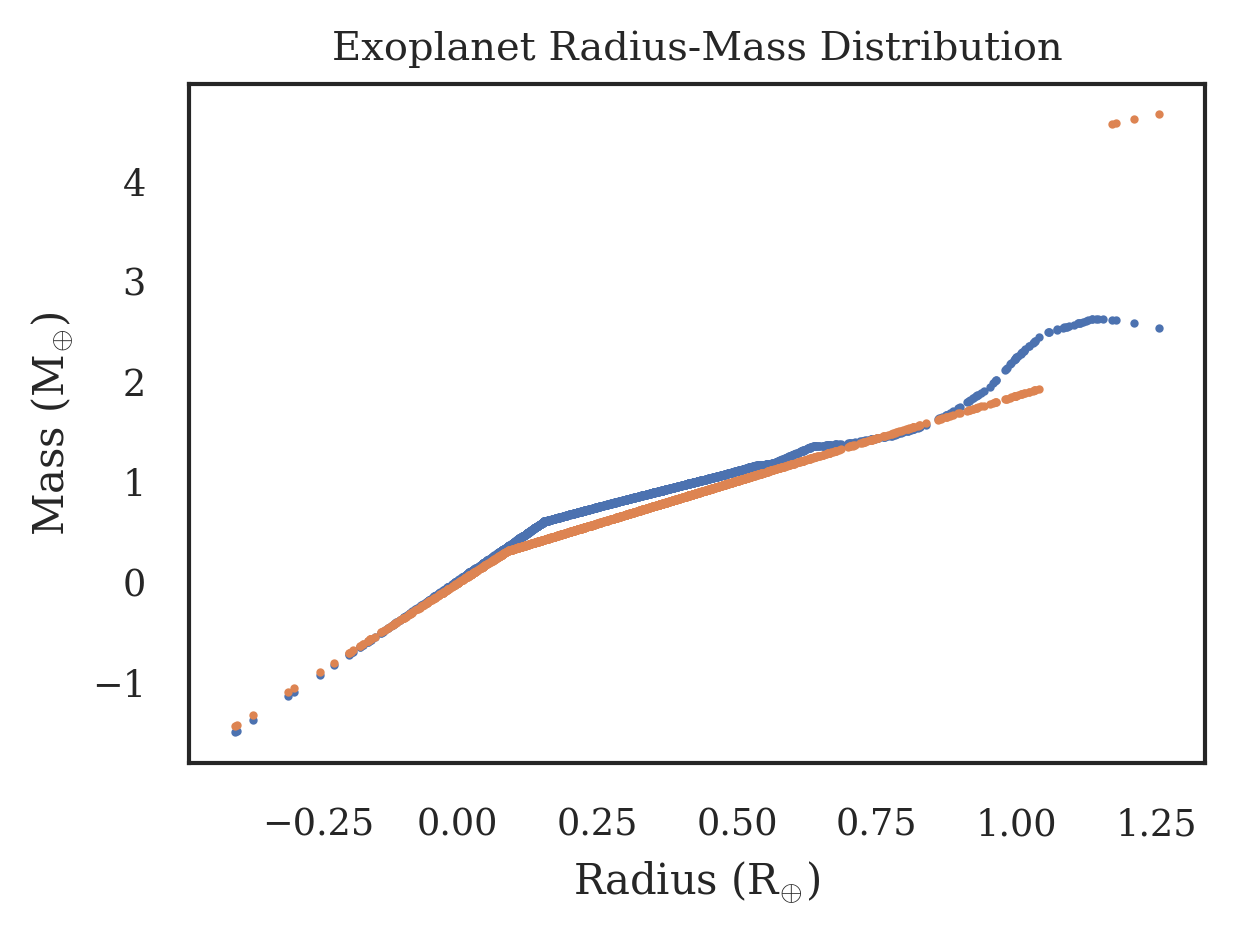

In [5]:
x = data['pl_rade']
x = numpy.log10(x)

model = load_model()
y = model(x)
data['mass_est'] = 10 ** y
y2 = ForecasterRM.forecaster(x)
data['mass_est_f'] = 10 ** y2

plot.scatter(x, y)
plot.scatter(x, y2)
plot.xlabel('Radius (R$_{\\oplus}$)')
plot.ylabel('Mass (M$_{\\oplus}$)')
plot.title('Exoplanet Radius-Mass Distribution')

# if save: plot.savefig(f'{path}/Figure 1.jpeg')

plot.show()

In [7]:
columns = ['Radius', 'ExoRM Prediction', 'Forecaster Prediction']
data[columns] = data[['pl_rade', 'mass_est', 'mass_est_f']]

save_data = data[columns].copy()
save_data[columns] = save_data[columns]

save_data[columns] = save_data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (5 - 1) - int(math.floor(math.log10(abs(x)))))
)

if save: save_data.to_csv(f'{path}/ExoRM_predictions.csv')
save_data

,Radius,ExoRM Prediction,Forecaster Prediction
pl_name,,,
K2-4 b,2.10000,7.0592,5.05950
K2-5 b,1.50000,4.2969,2.85770
K2-5 c,1.92000,6.2181,4.34540
K2-6 b,2.31220,8.0898,5.95760
K2-7 b,4.03520,19.0280,15.33500
...,...,...,...
EPIC 220554210 c,1.60000,4.7338,3.18860
EPIC 228836835 b,1.10000,1.4775,1.36760
EPIC 201170410.02,1.04700,1.2250,1.14580


In [ ]:
# from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
#
# table = NasaExoplanetArchive.query_criteria(
#     table = 'PS',
#     select = 'pl_name, pl_bmasse, pl_rade, pl_radeerr1, pl_radeerr2',
#     where = '''soltype='Published Confirmed' AND pl_controv_flag = 0'''
# )
#
# data = table.to_pandas()
#
# no_mass = data.groupby('pl_name')['pl_bmasse'].apply(lambda x: x.isnull().all())
# data = data[data['pl_name'].isin(no_mass[no_mass].index)].copy()
#
# data['error_score'] = (
#     abs(data['pl_radeerr1'] / data['pl_rade']) +
#     abs(data['pl_radeerr2'] / data['pl_rade'])
# ) / 2
#
# data = data.dropna(subset = ['pl_rade', 'error_score'])
# data = data.loc[data.groupby('pl_name')['error_score'].idxmin()]
# data['name_len'] = data['pl_name'].str.len()
# data = data.sort_values(by = ['name_len', 'pl_name'], ascending = True)
# data = data.drop('name_len', axis = 1)
#
# data.to_csv(data_path, index = False)
#
# data